In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
data=pd.read_csv('Bengaluru_House_Data.csv')

In [ ]:
data.head(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## data assumption

### dirty data problems

- have to convert area type column to one hot vector
- There is one missing value in location col `missing`
- In size column there are almsot 16 missing value in size column `missing`.
- In Size column bhk stands for (bathroom , kitchen and hall) so it is a numeric info , but in column it looking as categorical problem so we are going to extract only numeirc info ..
- since there are more than 5500 missing value in sociey column it would b better to drop it .

- IN TOTAL sqft column some values has inconsistent formats like there are some value in range like xx - yy and Some contain non-numeric info like "34.46Sq. Meter" or "4125Perch"

- the type of total sqft colum is obj but it should be int.
- In balcony column there are 609 missing value `missing`.
- There are outlier in square feet column
- There are outliers in bath column

### Tidiness problem

- In availabilty column we can make two categories either ready to move or available soon for simplicity

- In location column there is a category called electronic city but it has phases as well like electoric phase 1 or phase 2 so will combine them all as electronic city

- In location column we have so many categories , but i am only going to keep top 15 categories for model simplicity and will treat other as other ..



# what have been done so far

- removed balcony column
- filled missing values in size column by takinf top 3 random value of column
- sucessfully maked two categories in avalibilty col.
- in location column there we so many caterogors so i picked top 15 categories only and placred other as 'other' :)
- In size column removed , BHK and fetch only numeric info :)

- The colummn total sqft was inconsitent , corrected it .

-

In [ ]:
data['area_type'].sample(10)

,area_type
7287,Super built-up Area
10274,Built-up Area
2585,Built-up Area
11267,Super built-up Area
5127,Super built-up Area
10060,Super built-up Area
11919,Super built-up Area
1770,Plot Area
4459,Super built-up Area
5455,Super built-up Area


In [ ]:
data['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [ ]:
data['area_type'].isnull().sum()

np.int64(0)

In [ ]:
data['availability'].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [ ]:
data['availability'].isnull().sum()

np.int64(0)

In [ ]:
data['location']

,location
0,Electronic City Phase II
1,Chikka Tirupathi
2,Uttarahalli
3,Lingadheeranahalli
4,Kothanur
...,...
13315,Whitefield
13316,Richards Town
13317,Raja Rajeshwari Nagar
13318,Padmanabhanagar


In [ ]:
data['location'].isnull().sum()

np.int64(1)

In [ ]:
data['location'].value_counts(sort=True, ascending=False).head(30)

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
Yelahanka,213
Uttarahalli,186
Hebbal,177
Marathahalli,175


In [ ]:
data['size'].value_counts()

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [ ]:
data['society'].isnull().sum()

np.int64(5502)

In [ ]:
data['bath'].value_counts()

,count
bath,
2.0,6908
3.0,3286
4.0,1226
1.0,788
5.0,524
6.0,273
7.0,102
8.0,64
9.0,43


In [ ]:
data['balcony'].value_counts()

,count
balcony,
2.0,5113
1.0,4897
3.0,1672
0.0,1029


<Axes: >

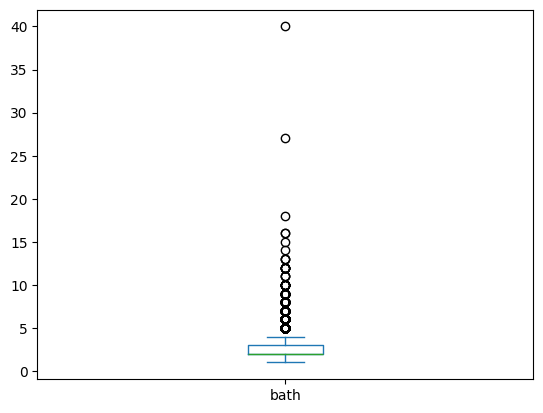

In [ ]:
data['bath'].plot(kind='box')

<Axes: xlabel='balcony'>

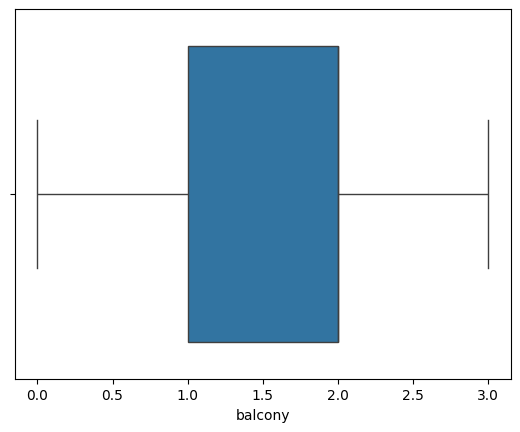

In [ ]:
sns.boxplot(x=data['balcony'])

In [ ]:
data['size'].isnull().sum()

np.int64(16)

In [ ]:
data['size'].value_counts()

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [ ]:
n=data['size'].isna().sum()

In [ ]:
data.loc[data['size'].isna(),'size']=np.random.choice(a=['2 BHK','3 BHK','4 Bedroom'],size=n)

In [ ]:
data['size'].isna().sum()

np.int64(0)

In [ ]:
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
data['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [ ]:
data['availability'].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [ ]:
data['availability']=data['availability'].apply(lambda x : 'Ready To Move' if x == 'Ready To Move' else 'Available Soon')

In [ ]:
data['availability'].value_counts()

,count
availability,
Ready To Move,10581
Available Soon,2739


In [ ]:
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
data['location'].value_counts(sort=True , ascending=False).head(30)

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
Yelahanka,213
Uttarahalli,186
Hebbal,177
Marathahalli,175


In [ ]:
def fetch_location(location):
  # Check if location is a string before calling lower()
  if isinstance(location, str):
    if 'whitefield' in location.lower():
      return 'Whitefield'
    elif 'sarjapur road' in location.lower():
      return 'Sarjapur Road'
    elif 'electronic city' in location.lower() or 'electronics city phase 1' in location.lower() or 'electronic city phase II' in location.lower():
      return 'Electronic City'
    elif 'kanakpura road' in location.lower():
      return 'Kanakpura Road'
    elif 'thanisandra' in location.lower():
      return 'Thanisandra'
    elif 'yelahanka' in location.lower():
      return 'Yelahanka'
    elif 'uttarahalli' in location.lower():
      return 'Uttarahalli'
    elif 'hebbal' in location.lower():
      return 'Hebbal'
    elif 'marathahalli' in location.lower():
      return 'Marathahalli'
    elif 'raja rajeshwari nagar' in location.lower():
      return 'Raja Rajeshwari Nagar'
    elif 'hennur road' in location.lower():
      return 'Hennur Road'
    elif 'bannerghatta road' in location.lower():
      return 'Bannerghatta Road'
    else:
      return 'Other'
  # If location is not a string (e.g., NaN), return 'Other' or handle it as needed
  else:
    return 'Other'

In [ ]:
data['location']=data['location'].apply(fetch_location)

In [ ]:
data['location'].value_counts()

,count
location,
Other,10392
Whitefield,547
Electronic City,532
Kanakpura Road,273
Yelahanka,263
Thanisandra,245
Hebbal,211
Uttarahalli,186
Raja Rajeshwari Nagar,177


In [ ]:
data['size'].value_counts()

,count
size,
2 BHK,5204
3 BHK,4316
4 Bedroom,831
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [ ]:
data['size']=data['size'].str.split(' ' ,expand=True)[0]

In [ ]:
data['size']=data['size'].astype(int)

In [ ]:
data['size'].value_counts()

,count
size,
2,5533
3,4863
4,1422
1,656
5,356
6,221
7,100
8,89
9,54


In [ ]:
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,NaN,1200,2.0,1.0,51.00


In [ ]:
data.rename(columns={'size': 'bathroom,house,kitchen'}, inplace=True)


In [ ]:
data.head()

,area_type,availability,location,"bathroom,house,kitchen",society,total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,NaN,1200,2.0,1.0,51.00


In [ ]:
data.drop(columns=['society'],inplace=True)

In [ ]:
data.head()

,area_type,availability,location,"bathroom,house,kitchen",total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,1200,2.0,1.0,51.00


In [ ]:
data['total_sqft']=pd.to_numeric(data['total_sqft'],errors='coerce')

In [ ]:
data['total_sqft'].isna().sum()

np.int64(247)

In [ ]:
n=data['total_sqft'].isna().sum()

values=data['total_sqft'].dropna()

data.loc[data['total_sqft'].isna(),'total_sqft'] = np.random.choice(values,size=n)

In [ ]:
data['total_sqft'].isna().sum()

np.int64(0)

In [ ]:
data['total_sqft']=data['total_sqft'].astype(int)

In [ ]:
data.head()

,area_type,availability,location,"bathroom,house,kitchen",total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,1200,2.0,1.0,51.00


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_type               13320 non-null  object 
 1   availability            13320 non-null  object 
 2   location                13320 non-null  object 
 3   bathroom,house,kitchen  13320 non-null  int64  
 4   total_sqft              13320 non-null  int64  
 5   bath                    13247 non-null  float64
 6   balcony                 12711 non-null  float64
 7   price                   13320 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 832.6+ KB


In [ ]:
data.head()

,area_type,availability,location,"bathroom,house,kitchen",total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,1200,2.0,1.0,51.00


In [ ]:
data['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [ ]:
data.head()

,area_type,availability,location,"bathroom,house,kitchen",total_sqft,bath,balcony,price
0,Super built-up Area,Available Soon,Electronic City,2,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Other,4,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Other,3,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Other,2,1200,2.0,1.0,51.00


<Axes: ylabel='price'>

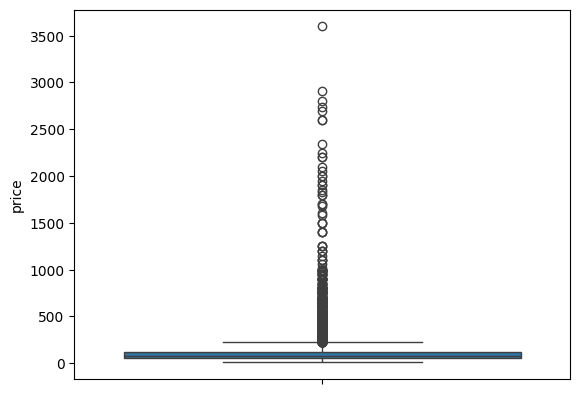

In [ ]:
sns.boxplot(data['price'])

In [ ]:
data=data[data['price']<1000]

<Axes: ylabel='price'>

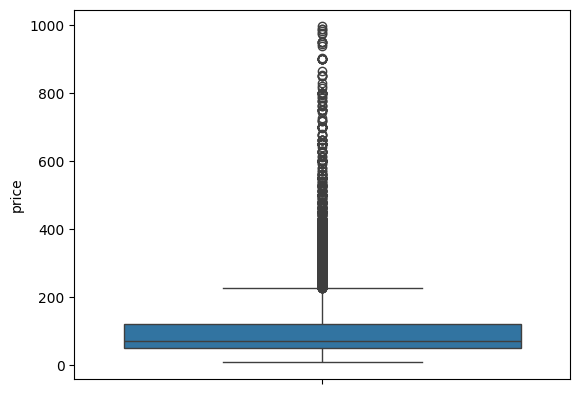

In [ ]:
sns.boxplot(data['price'])

<Axes: ylabel='total_sqft'>

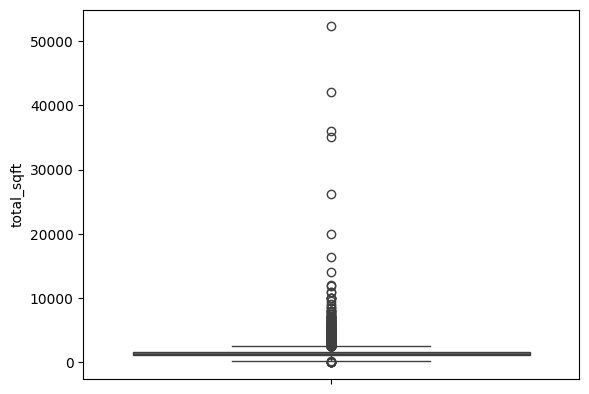

In [ ]:
sns.boxplot(data['total_sqft'])

In [ ]:
data=data[data['total_sqft']<7000]

<Axes: ylabel='total_sqft'>

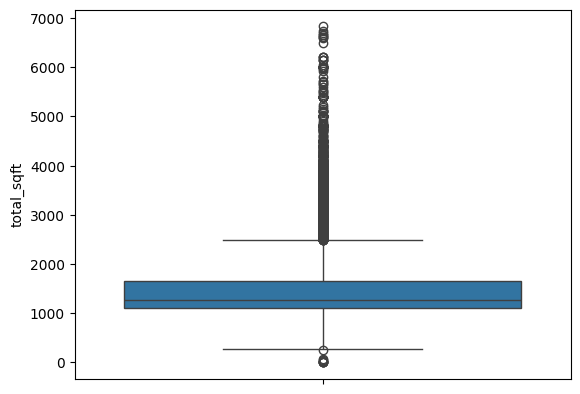

In [ ]:
sns.boxplot(data['total_sqft'])

In [ ]:
data=data[data['total_sqft']>10]

<Axes: xlabel='total_sqft', ylabel='price'>

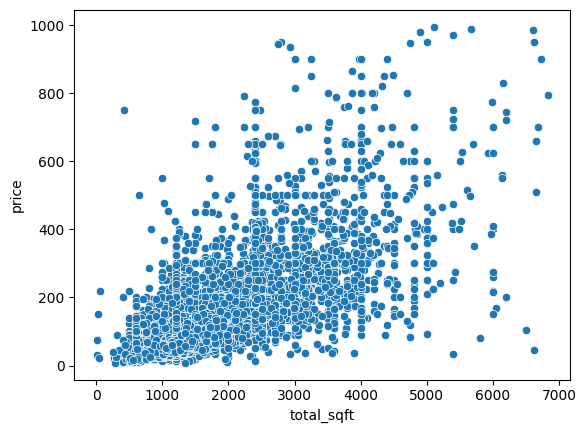

In [ ]:
sns.scatterplot(x=data['total_sqft'],y=data['price'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_type               13233 non-null  object 
 1   availability            13233 non-null  object 
 2   location                13233 non-null  object 
 3   bathroom,house,kitchen  13233 non-null  int64  
 4   total_sqft              13233 non-null  int64  
 5   bath                    13161 non-null  float64
 6   balcony                 12648 non-null  float64
 7   price                   13233 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 930.4+ KB


In [ ]:
data.groupby('location')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
location,,,,,,,,
Bannerghatta Road,149.0,84.959933,56.854892,18.500,57.00,71.00,94.00,500.0
Electronic City,531.0,53.345235,41.009025,12.000,33.28,44.10,64.65,700.0
Hebbal,211.0,166.048531,122.738791,38.000,79.84,120.00,203.50,650.0
Hennur Road,153.0,104.693758,75.445930,23.000,65.21,84.00,110.00,515.0
Kanakpura Road,273.0,70.533791,36.001572,19.695,45.00,63.00,88.00,250.0
Marathahalli,175.0,102.213714,72.433573,35.000,58.00,76.00,115.50,650.0
Other,10315.0,110.069595,108.087173,8.440,50.00,75.00,125.00,995.0
Raja Rajeshwari Nagar,177.0,64.578701,46.447581,21.000,43.90,53.56,65.00,350.0
Sarjapur Road,14.0,131.857143,93.108586,59.000,74.50,93.00,145.00,342.0


In [ ]:
data.isnull().sum()

,0
area_type,0
availability,0
location,0
"bathroom,house,kitchen",0
total_sqft,0
bath,72
balcony,585
price,0


In [ ]:
data['bath'].head()

,bath
0,2.0
1,5.0
2,2.0
3,3.0
4,2.0


In [ ]:
data.rename(columns={'bathroom,house,kitchen': 'bedroom,hall,kitchen'}, inplace=True)


In [ ]:
data['bedroom,hall,kitchen,bath']=data['bedroom,hall,kitchen']+data['bath']

In [ ]:
data.drop(columns=['bedroom,hall,kitchen','bath'],inplace=True)

In [ ]:
data.head()

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,39.07,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,120.00,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,62.00,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,95.00,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,51.00,4.0


<Axes: xlabel='bedroom,hall,kitchen,bath', ylabel='price'>

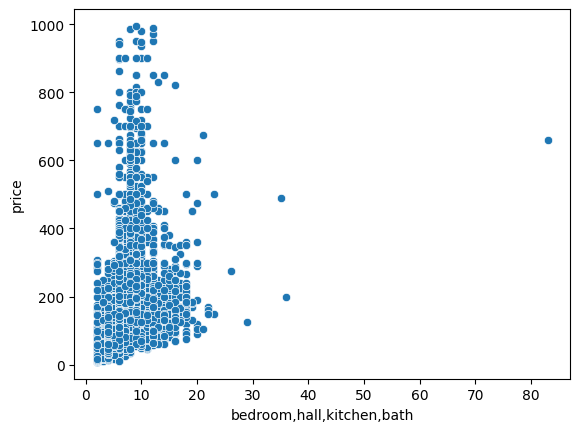

In [ ]:
sns.scatterplot(x=data['bedroom,hall,kitchen,bath'],y=data['price'])

In [ ]:
data=data[data['bedroom,hall,kitchen,bath']<25]

<Axes: xlabel='bedroom,hall,kitchen,bath', ylabel='price'>

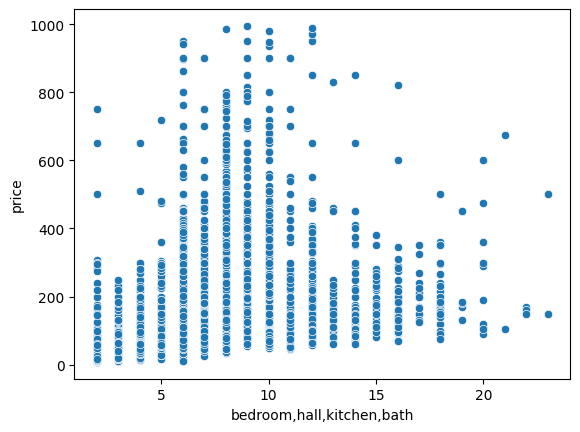

In [ ]:
sns.scatterplot(x=data['bedroom,hall,kitchen,bath'],y=data['price'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13156 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   area_type                  13156 non-null  object 
 1   availability               13156 non-null  object 
 2   location                   13156 non-null  object 
 3   total_sqft                 13156 non-null  int64  
 4   balcony                    12645 non-null  float64
 5   price                      13156 non-null  float64
 6   bedroom,hall,kitchen,bath  13156 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 822.2+ KB


In [ ]:
data['balcony'].fillna(data['balcony'].median(),inplace=True)

<ipython-input-72-2660c485932c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['balcony'].fillna(data['balcony'].median(),inplace=True)


In [ ]:
data.isnull().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
balcony,0
price,0
"bedroom,hall,kitchen,bath",0


In [ ]:
data.corr(numeric_only=True)['price']

,price
total_sqft,0.720855
balcony,0.139817
price,1.000000
"bedroom,hall,kitchen,bath",0.529919


In [ ]:
data.head()

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,39.07,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,120.00,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,62.00,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,95.00,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,51.00,4.0


In [ ]:
pd.crosstab(index=data['area_type'], columns=data['availability'],normalize='columns')*100


availability,Available Soon,Ready To Move
area_type,,
Built-up Area,10.063838,20.308777
Carpet Area,0.863688,0.609930
Plot Area,7.923395,16.677785
Super built-up Area,81.149080,62.403507


<Axes: xlabel='area_type', ylabel='price'>

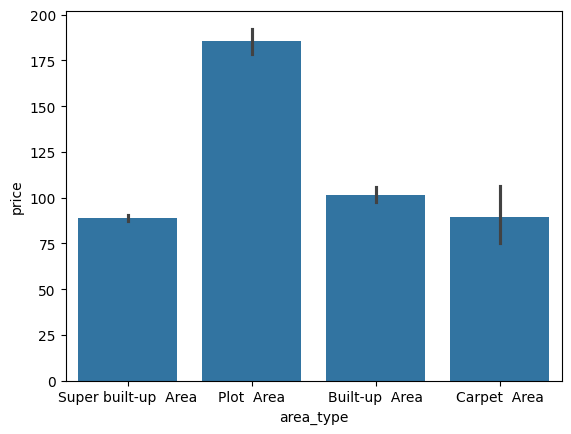

In [ ]:
sns.barplot(x=data['area_type'],y=data['price'])

In [ ]:
data.head()

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,39.07,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,120.00,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,62.00,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,95.00,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,51.00,4.0


<ipython-input-79-5a69930c1943>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['total_sqft'])


<Axes: xlabel='total_sqft', ylabel='Density'>

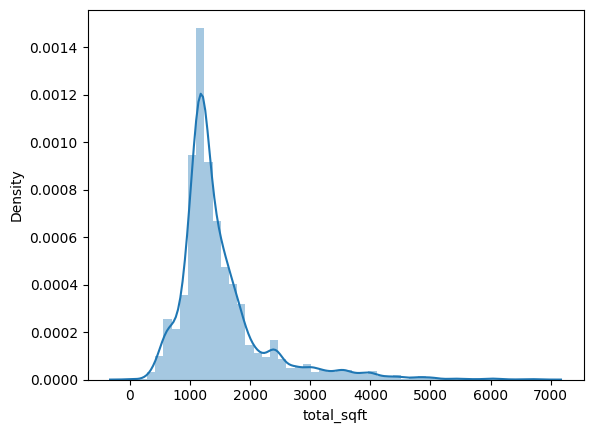

In [ ]:
sns.distplot(data['total_sqft'])

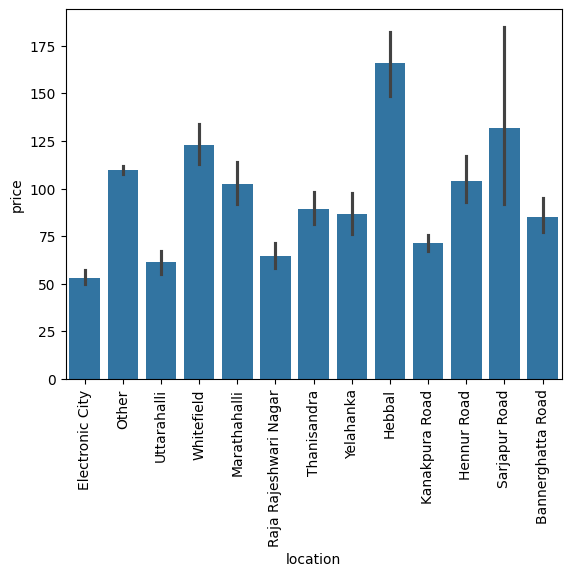

In [ ]:
sns.barplot(x=data['location'],y=data['price'])
plt.xticks(rotation=90)
plt.show()

<Axes: ylabel='total_sqft'>

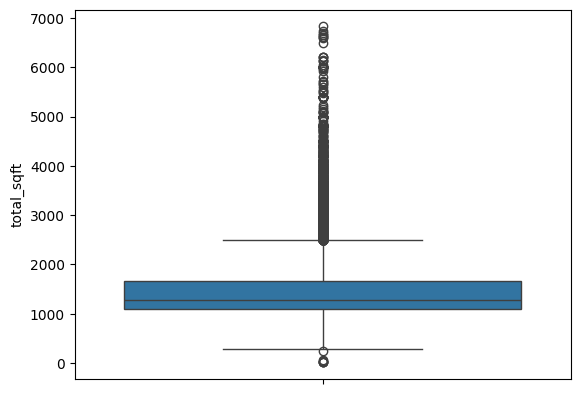

In [ ]:
sns.boxplot(data['total_sqft'])

In [ ]:
data[data['total_sqft']>6000] # they are not looking an outliers

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
1090,Plot Area,Ready To Move,Other,6136,2.0,560.0,8.0
2024,Built-up Area,Ready To Move,Other,6150,1.0,830.0,13.0
2368,Plot Area,Ready To Move,Other,6040,2.0,170.0,9.0
2826,Built-up Area,Ready To Move,Other,6200,0.0,200.0,18.0
3425,Super built-up Area,Ready To Move,Other,6200,2.0,720.0,10.0
4195,Super built-up Area,Ready To Move,Other,6600,2.0,986.0,8.0
5181,Plot Area,Ready To Move,Other,6613,2.0,950.0,12.0
7179,Plot Area,Ready To Move,Other,6136,2.0,550.0,8.0
7972,Super built-up Area,Ready To Move,Other,6830,2.0,795.0,9.0
8087,Super built-up Area,Ready To Move,Electronic City,6613,0.0,45.4,2.0


In [ ]:
data.head()

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,39.07,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,120.00,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,62.00,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,95.00,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,51.00,4.0


<Axes: ylabel='price'>

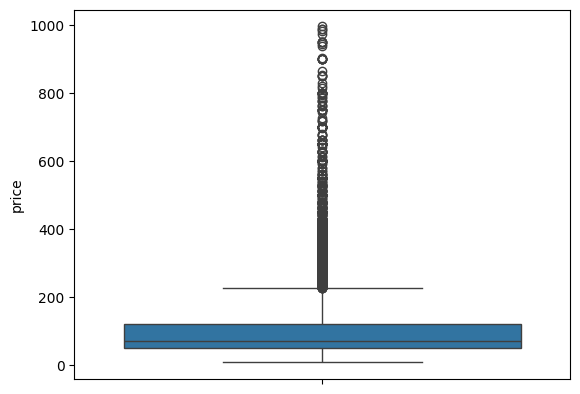

In [ ]:
sns.boxplot(data['price'])

In [ ]:
data[data['price']>820] # they are also not looking an outliers

,area_type,availability,location,total_sqft,balcony,price,"bedroom,hall,kitchen,bath"
1044,Plot Area,Ready To Move,Other,3968,2.0,900.0,11.0
1678,Plot Area,Ready To Move,Whitefield,3250,3.0,900.0,10.0
2024,Built-up Area,Ready To Move,Other,6150,1.0,830.0,13.0
2649,Plot Area,Ready To Move,Other,3000,2.0,900.0,11.0
2981,Super built-up Area,Ready To Move,Other,3875,2.0,864.0,6.0
4195,Super built-up Area,Ready To Move,Other,6600,2.0,986.0,8.0
4403,Plot Area,Ready To Move,Other,3250,1.0,850.0,9.0
4602,Plot Area,Ready To Move,Whitefield,4356,1.0,850.0,9.0
5181,Plot Area,Ready To Move,Other,6613,2.0,950.0,12.0
5193,Plot Area,Ready To Move,Other,2790,0.0,950.0,6.0


In [ ]:
data.corr(numeric_only=True)['price']

,price
total_sqft,0.720855
balcony,0.139817
price,1.000000
"bedroom,hall,kitchen,bath",0.529919


<ipython-input-87-a37b86cbbd53>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(data['price']))


<Axes: xlabel='price', ylabel='Density'>

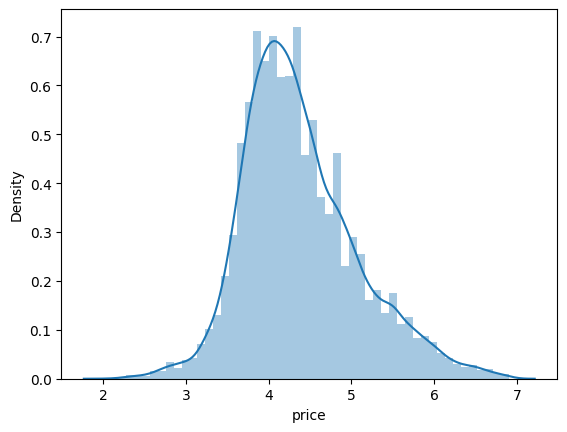

In [ ]:
sns.distplot(np.log(data['price']))

In [ ]:
x=data.drop(columns=['price'])
y=np.log(data['price'])

In [ ]:
from sklearn.model_selection import train_test_split , cross_val_score , GridSearchCV

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=33)


In [ ]:
x

,area_type,availability,location,total_sqft,balcony,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,4.0
...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453,0.0,9.0
13316,Super built-up Area,Ready To Move,Other,3600,2.0,9.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,1.0,4.0
13318,Super built-up Area,Available Soon,Other,4689,1.0,8.0


In [ ]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge

In [ ]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler , PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


In [ ]:
x

,area_type,availability,location,total_sqft,balcony,"bedroom,hall,kitchen,bath"
0,Super built-up Area,Available Soon,Electronic City,1056,1.0,4.0
1,Plot Area,Ready To Move,Other,2600,3.0,9.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,3.0,5.0
3,Super built-up Area,Ready To Move,Other,1521,1.0,6.0
4,Super built-up Area,Ready To Move,Other,1200,1.0,4.0
...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453,0.0,9.0
13316,Super built-up Area,Ready To Move,Other,3600,2.0,9.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,1.0,4.0
13318,Super built-up Area,Available Soon,Other,4689,1.0,8.0


# Linear regression

In [ ]:
step1=ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
    ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')

step2=LinearRegression()

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')

print("test score :",r2_score(y_pred,y_test))
print("average scoer on cv :",scores.mean())

test score : 0.4401128172686163
average scoer on cv : 0.6566357075929257


# Ridge regression

In [ ]:
step1=ColumnTransformer(transformers=[(
    'col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
    ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')

step2=Ridge(alpha=1)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)

])

pipe.fit(X_train,y_train)

param_grid={
    'step2__alpha':[1,2,4,6,8,10,14,18,20]
}

grid_search=GridSearchCV(pipe,param_grid,cv=5,scoring='r2')

grid_search.fit(X_train,y_train)

print("best parameter :",grid_search.best_params_)
print("best score :",grid_search.best_score_)



best parameter : {'step2__alpha': 2}
best score : 0.6566402567341755


# lasso regression

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf1', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 2]),
    ('col_tnf2', StandardScaler(), [3, 4, 5])
], remainder='passthrough')

# Model
step2 = Lasso(alpha=0)  # working best with alpha = 0 :)

# Pipeline
pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# Hyperparameter grid
param_grid = {
    'step2__alpha': [1, 2, 4, 6, 8, 10, 14, 18, 20]
}

# GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')

# Fit ONLY the grid_search (not pipe separately)
grid_search.fit(X_train, y_train)

# Get best model and predict
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Print scores
print("Best parameter:", grid_search.best_params_)
print("CV Best Score (train avg):", grid_search.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))

Best parameter: {'step2__alpha': 1}
CV Best Score (train avg): -0.0007309044486279337
Test R2 Score: -0.00023541460318887708


# polynomial regression

In [ ]:
pipeLine_for_polynomialFeature=Pipeline([
    ('poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('standardScaler',StandardScaler())
])

preprocessing=ColumnTransformer([
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
    ('col_tnf2',pipeLine_for_polynomialFeature,[3,4,5])

],remainder='passthrough')


pipe=Pipeline([
    ('step1',preprocessing),
    ('step2',LinearRegression())
])

pipe.fit(X_train,y_train)


param_grid={
    'step1__col_tnf2__poly__degree':[1,2,3,4,5,6]

}

grid_search=GridSearchCV(pipe,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)

grid_search.fit(X_train,y_train)

print("best parameter :",grid_search.best_params_)
print("best score :",grid_search.best_score_)


best parameter : {'step1__col_tnf2__poly__degree': 5}
best score : 0.7168755703547021


# Decison Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

step1=ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
     ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')



step2=DecisionTreeRegressor(max_depth=7 , min_samples_leaf=2,min_samples_split=2) # got them after hyperparameter tuning

pipe=Pipeline([
  ('step1',step1),
   ('step2',step2)
])


pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')
print("test score",r2_score(y_test,y_pred))
print("average scoer on cv :",scores.mean())

test score 0.7301686463027663
average scoer on cv : 0.7157305258958196


# Random forest regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

step1=ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
     ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')

step2=RandomForestRegressor(   # producing best result on these paramters
    n_estimators=100,
    random_state=42,
    min_samples_split=4,
    min_samples_leaf=2,
    max_depth=9
)


pipe=Pipeline([
        ('step1',step1),
        ('step2',step2)
])

pipe.fit(X_train,y_train)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')

y_pred=pipe.predict(X_test)

print("test score :",r2_score(y_test,y_pred))
print("Average score on cross validation :",scores.mean())

test score : 0.755485469263453
Average score on cross validation : 0.7446737317522037


# Gradient boosting regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

step1=ColumnTransformer(transformers=[
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
  ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')

step2=GradientBoostingRegressor( # these are the values of parameter where getting highest score (could be improve more if do more hyperparameter tuning)
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    min_samples_split=4,
    min_samples_leaf=2,

)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2),

])


pipe.fit(X_train,y_train)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')

y_pred=pipe.predict(X_test)

print("test score :",r2_score(y_test,y_pred))
print("Average score on cv",scores.mean())
print("mean absolute error :",mean_absolute_error(y_test,y_pred))

test score : 0.7624516755267262
Average score on cv 0.7484902687560033
mean absolute error : 0.2456525697991078


In [ ]:
from xgboost import XGBRegressor

step1=step1=ColumnTransformer(transformers=[
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2]),
  ('col_tnf2',StandardScaler(),[3,4,5])
],remainder='passthrough')


step2=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])


param_grid={
    'step2__n_estimators':[100,200,300],
    'step2__learning_rate':[0.01,0.1,0.2],
    'step2__max_depth':[3,4,5,7,9],
    'step2__subsample':[0.8,0.9,1.0],
    'step2__colsample_bytree':[0.8,0.9,1.0],
    'step2__gamma':[0,1,2]
}
grid_search=GridSearchCV(pipe,param_grid=param_grid,cv=5,scoring='r2')

grid_search.fit(X_train,y_train)

print("best parameter :",grid_search.best_params_)
print("best score :",grid_search.best_score_)

best parameter : {'step2__colsample_bytree': 0.9, 'step2__gamma': 0, 'step2__learning_rate': 0.2, 'step2__max_depth': 5, 'step2__n_estimators': 100, 'step2__subsample': 1.0}
best score : 0.7510990920082763
